# Notebook 02 - Data Analysis

In this notebook, we perform a basic exploratory data analysis on the dataset. Some of the visualizations included here may not be directly used in later stages or may not have a specific interpretation. They are primarily intended to practice data extraction, manipulation, and visualization techniques.

## Setup 

In [57]:
# General
import numpy as np                     
import pandas as pd      
import re              

# Plotting Options
from matplotlib import pyplot as plt                           
import seaborn as sns                                          
plt.rcParams['text.usetex'] = True                             
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  

# File management
from pathlib import Path                  
import os                     

# Defines a function to find the project root directory by looking for a specific marker (default is 'data')
def find_project_root(start=Path.cwd(), marker='data'): 
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root() 
os.chdir(PROJECT_ROOT) # go to the root of the project 

In [58]:
df_reviews = pd.read_csv('data/dataframes/gold/reviews.csv')

In [59]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   unique_id               10000 non-null  int64 
 1   asin                    10000 non-null  object
 2   helpful                 10000 non-null  object
 3   rating                  10000 non-null  int64 
 4   reviewText              10000 non-null  object
 5   reviewTime              10000 non-null  object
 6   reviewerID              10000 non-null  object
 7   reviewerName            9966 non-null   object
 8   summary                 9998 non-null   object
 9   unixReviewTime          10000 non-null  int64 
 10  normalized_review_time  10000 non-null  object
 11  normalized_review       10000 non-null  object
 12  sentiment               10000 non-null  object
dtypes: int64(3), object(10)
memory usage: 1015.8+ KB


# Years with most reviews

In [60]:
df_reviews['normalized_review_time'] = pd.to_datetime(df_reviews['normalized_review_time'])

In [61]:
df_reviews['review_year'] = df_reviews['normalized_review_time'].dt.year
df_reviews.head()

,unique_id,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,normalized_review_time,normalized_review,sentiment,review_year
0,5957,B002HJV4DE,"[1, 1]",1,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400,2013-10-08,great short read i didnt want to put it down s...,positive,2013
1,1776,B001A06VJ8,"[0, 1]",1,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000,2012-12-31,i did not expect this type of book to be in li...,positive,2012
2,3744,B0021L9YDK,"[6, 6]",1,Aislinn is a little girl with big dreams. Afte...,"12 7, 2009",A3J5NN6MJK4M4A,"Aubrie A. Dionne ""Fantasy, Sci Fi Author""",A story of a little girl with big dreams.,1260144000,2009-12-07,aislinn is a little girl with big dreams after...,positive,2009
3,13641,B0038NN38W,"[1, 1]",0,This has the makings of a good story... unfort...,"08 18, 2011",A531QY5K7JVXI,Chicano,This story has potential but ultimately disapp...,1313625600,2011-08-18,this has the makings of a good story unfortuna...,negative,2011
4,4448,B002AJ7X2C,"[1, 1]",1,I got this because I like collaborated short s...,"03 8, 2010",AN8ELR6AHMMQ,"Jessss ""I read to find stories that inspire m...",Good thriller,1268006400,2010-03-08,i got this because i like collaborated short s...,positive,2010


In [62]:
# Counting number of year appearances

years = df_reviews['review_year'].value_counts().to_frame()
df_years = years.reset_index()
df_years

,review_year,count
0,2013,3459
1,2012,2087
2,2014,1549
3,2011,1529
4,2010,851
5,2009,369
6,2008,133
7,2007,15
8,2006,3
9,2005,2


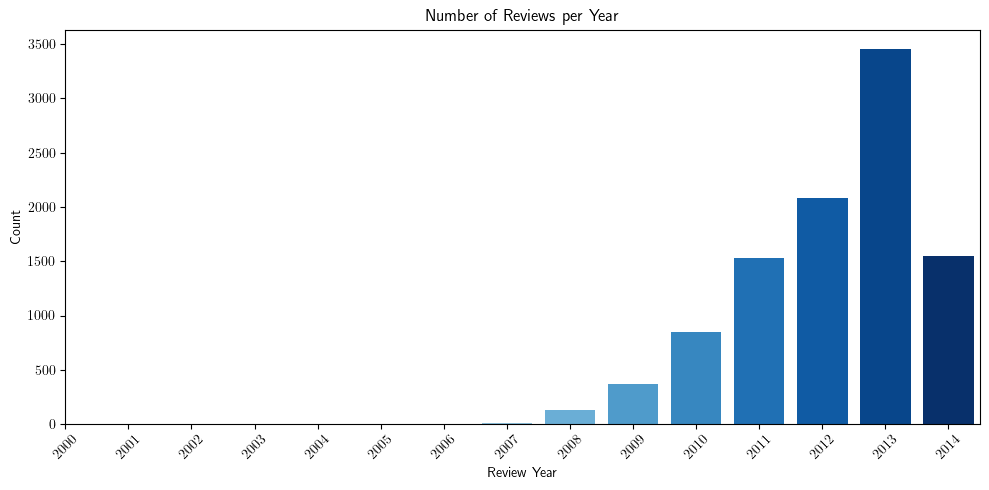

In [63]:
# Generating time series

df_years = df_years.sort_values(by='review_year')
gradient = np.linspace(0, 1, len(df_years))
colors = plt.cm.Blues(gradient)

plt.figure(figsize=(10, 5))
plt.bar(df_years['review_year'], df_years['count'], color=colors)
plt.xlim(2000, 2014.5)
plt.xticks(range(2000, 2015), rotation=45)
plt.xlabel('Review Year')
plt.ylabel('Count')
plt.title('Number of Reviews per Year')
plt.tight_layout()
plt.savefig('data/plots/reviews_per_year.png', dpi=300)
plt.show()


## Distribution of sentiments

### Absolute distribution of sentiments

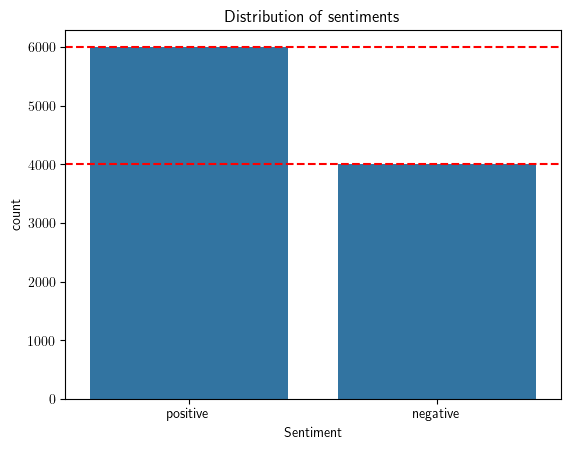

In [72]:
sns.countplot(x = 'sentiment', data = df_reviews)
plt.title('Distribution of sentiments')
plt.xlabel('Sentiment')
plt.axhline(y = 6000, color = 'red', linestyle = '--')
plt.axhline(y = 4000, color = 'red', linestyle = '--')
plt.savefig('data/plots/sentiment_distribution.png', dpi=300)
plt.show()

In [65]:
# absolute number of sentiments 

positive_count = (df_reviews['sentiment']=='positive').sum()
negative_count = (df_reviews['sentiment']=='negative').sum()
print(f'Number of positive sentiments: ', positive_count)
print(f'Number of positive sentiments: ', negative_count)


Number of positive sentiments:  6000
Number of positive sentiments:  4000


### Distribution of sentiments per year

We will consider the years from 2007 onwards because we have more data.

In [66]:
review_year = df_reviews[['review_year','sentiment']].value_counts().to_frame()
df_review_year = review_year.sort_values(by='review_year',ascending=False).reset_index()
df_review_year

,review_year,sentiment,count
0,2014,positive,1002
1,2014,negative,547
2,2013,negative,1324
3,2013,positive,2135
4,2012,positive,1143
5,2012,negative,944
6,2011,positive,682
7,2011,negative,847
8,2010,positive,568
9,2010,negative,283


For our purposes, we need to split this dataframe into a column with positive values only and negative values only

In [67]:
df_review_year_pivot = df_review_year.pivot(index='review_year', columns='sentiment', values='count').fillna(0).reset_index()

df_review_year_pivot = df_review_year_pivot.rename(columns={'positive': 'positive_sentiments', 'negative': 'negative_sentiments'})

df_review_year_pivot['positive_sentiments'] = df_review_year_pivot['positive_sentiments'].astype(int)
df_review_year_pivot['negative_sentiments'] = df_review_year_pivot['negative_sentiments'].astype(int)

df_review_year_pivot


sentiment,review_year,negative_sentiments,positive_sentiments
0,2000,0,1
1,2001,0,1
2,2002,0,1
3,2005,0,2
4,2006,0,3
5,2007,0,15
6,2008,7,126
7,2009,48,321
8,2010,283,568
9,2011,847,682


We will take the distribution from 2008 onwards since we have more data starting from it

In [68]:
df_review_year_pivot = df_review_year_pivot[df_review_year_pivot['review_year'] >= 2008].reset_index(drop=True)
df_review_year_pivot

sentiment,review_year,negative_sentiments,positive_sentiments
0,2008,7,126
1,2009,48,321
2,2010,283,568
3,2011,847,682
4,2012,944,1143
5,2013,1324,2135
6,2014,547,1002


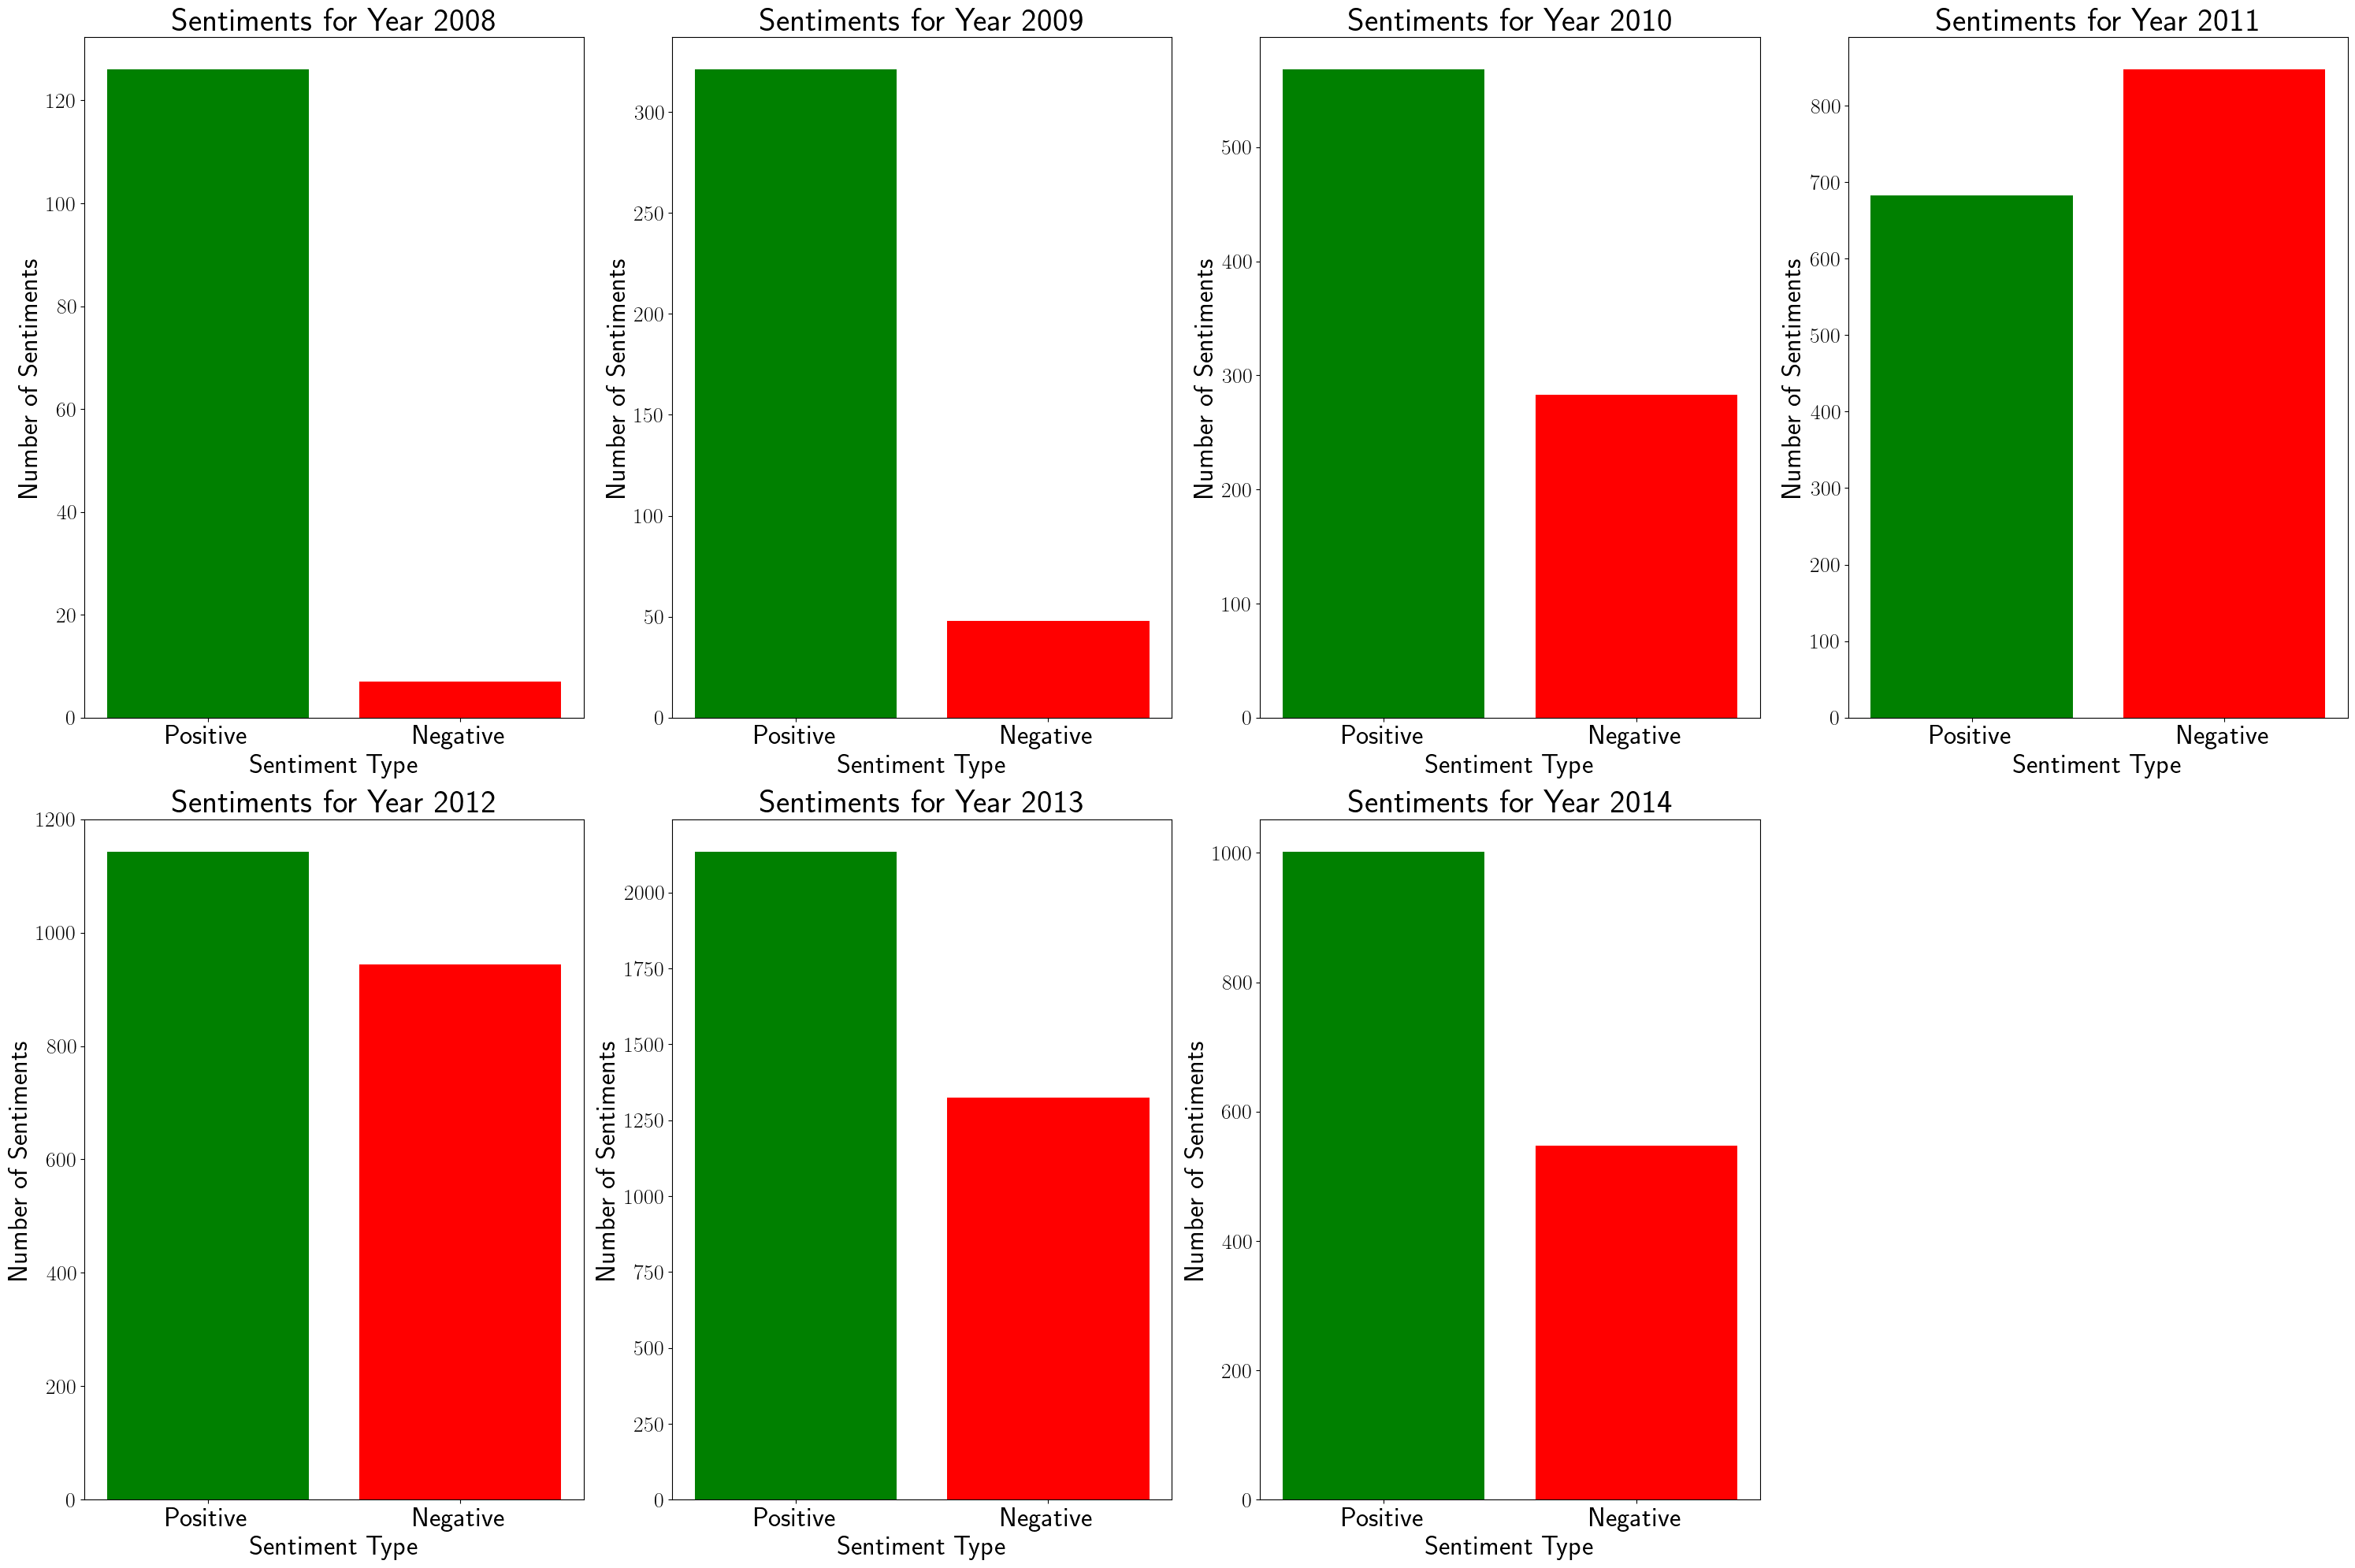

In [69]:
fig, axes = plt.subplots(2, 4, figsize=(30, 20))
axes = axes.flatten()

for i, row in df_review_year_pivot.iterrows():
    year = int(row['review_year'])
    pos = row['positive_sentiments']
    neg = row['negative_sentiments']

    axes[i].bar(['Positive', 'Negative'], [pos, neg], color=['green', 'red'])
    axes[i].set_title(f'Sentiments for Year {year}', fontsize=30)
    axes[i].set_ylabel('Number of Sentiments', fontsize=25)
    axes[i].set_xlabel('Sentiment Type', fontsize=25)
    axes[i].tick_params(axis='x', labelsize=25)  
    axes[i].tick_params(axis='y', labelsize=20)  

axes[7].set_visible(False)

plt.tight_layout()
plt.savefig('data/plots/sentiment_distribution_per_year.png', dpi=300)
plt.show()